### Logistic Regression with Class Weight

In [1]:
# Importing the library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, classification_report, roc_curve

from imbalanced import over_sampling, under_sampling
from helper import save_model, load_model
from ML_helper import cross_validation, train_and_evaluate

In [2]:
# Configuration
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
pd.set_option('display.max_columns', 500)

# Filter Warning
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Reading the dataset
df = pd.read_csv("Modified Data/ML_ready.csv")
df.head()

,Gender,Age Range,Heart Attack,Angina or Coronary Heart Disease,Stroke,High Blood Pressure,Cholesterol Is High,Taking medicine for high cholesterol,Diabetes,Kidney Disease,Arthritis,General Health,Number of Days Physical Health Not Good,Number of Days Mental Health Not Good,Exercise in Past 30 Days,Physical activities frequence,Smoked at Least 100 Cigarettes,Smokeless Tobacco Products,E-cigarettes Frequency,Days in past 30 had alcoholic beverage,BMI_Category
0,0,12,0,0,0,1,0,0,1,0,0,3,30,30,0,0,0,0,0,0,3
1,0,12,0,0,0,1,1,1,0,0,1,3,30,30,1,0,0,0,0,0,2
2,0,12,0,0,0,1,1,1,0,0,1,1,6,2,1,5,1,0,0,0,1
3,0,11,0,0,0,0,0,0,0,0,1,3,2,30,1,0,0,0,0,0,2
4,0,11,0,0,0,1,0,0,1,0,1,1,30,30,1,0,0,1,0,2,2


In [4]:
target = "Heart Attack"

In [5]:
X = df.drop(columns=[target])
y = df[target]

In [6]:
metrices = {
    "Confusion_metrix": confusion_matrix,
    "F1_score": f1_score,
    "AUC-ROC_Score": roc_auc_score,
    "Classification_report": classification_report
    }

### Train and test Model

In [7]:
# Split dataset into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
# Manually setting weights: class 0 has weight 1, class 1 has weight 3
weights = {0: 1, 1: 18}

model = LogisticRegression(class_weight=weights, solver='liblinear')

Logistic Regression with Class Weight
🔹 AUC-ROC Score: 0.8835
🔹 F1 Score: 0.3133
🔹 Accuracy Score: 0.8142
📌 Confusion Matrix:
[[66892 15083]
 [ 1017  3673]]

📌 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.89     81975
           1       0.20      0.78      0.31      4690

    accuracy                           0.81     86665
   macro avg       0.59      0.80      0.60     86665
weighted avg       0.94      0.81      0.86     86665




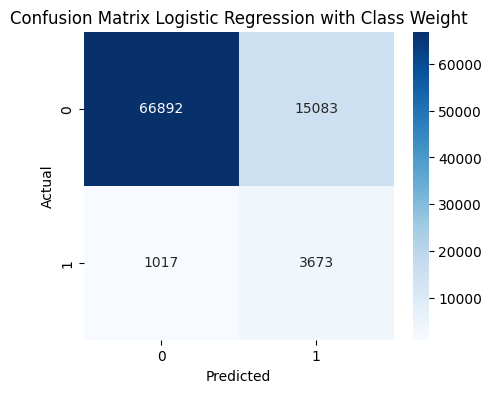

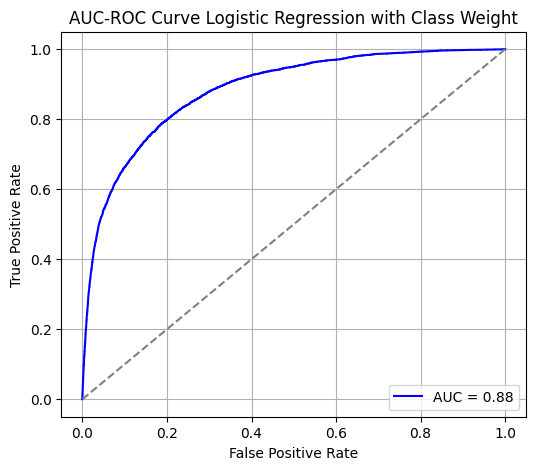

LogisticRegression(class_weight={0: 1, 1: 18}, solver='liblinear')

In [21]:
train_and_evaluate(model, X_train, X_test, y_train, y_test, "Logistic Regression with Class Weight")

### Finding best params

In [10]:
# Define model
logistic = LogisticRegression(solver='liblinear', max_iter=1000)

# Define hyperparameter
param_grid = {'C':  [0.001, 0.01, 0.1, 1, 10, 100], 
              'penalty': ['l1', 'l2'], 
              'class_weight':[{0: 1, 1: 3}, {0: 1, 1: 6}, 
                              {0: 1, 1: 9}, {0: 1, 1: 12}]
                              }


# Use GridSearchCV for tuning regularization
grid_search = GridSearchCV(logistic, param_grid, cv=5, scoring='roc_auc', verbose=1)
grid_search.fit(X, y)

# Best hyperparameters
print(f"🔹 Best Parameters: {grid_search.best_params_}")
print(f"🔹 Best AUC-ROC Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': [{0: 1, 1: 3}, {0: 1, 1: 6},
                                          {0: 1, 1: 9}, {0: 1, 1: 12}],
                         'penalty': ['l1', 'l2']},
             scoring='roc_auc', verbose=1)

🔹 Best Parameters: {'C': 0.1, 'class_weight': {0: 1, 1: 6}, 'penalty': 'l2'}
🔹 Best AUC-ROC Score: 0.8814


In [11]:
# Train model with best C and penalty
best_model = LogisticRegression(penalty=grid_search.best_params_['penalty'], 
                                C=grid_search.best_params_['C'], 
                                solver='liblinear', max_iter=1000)

Logistic Regression with Class Weight
🔹 AUC-ROC Score: 0.8835
🔹 F1 Score: 0.3226
🔹 Accuracy Score: 0.9488
📌 Confusion Matrix:
[[81174   801]
 [ 3634  1056]]

📌 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     81975
           1       0.57      0.23      0.32      4690

    accuracy                           0.95     86665
   macro avg       0.76      0.61      0.65     86665
weighted avg       0.94      0.95      0.94     86665




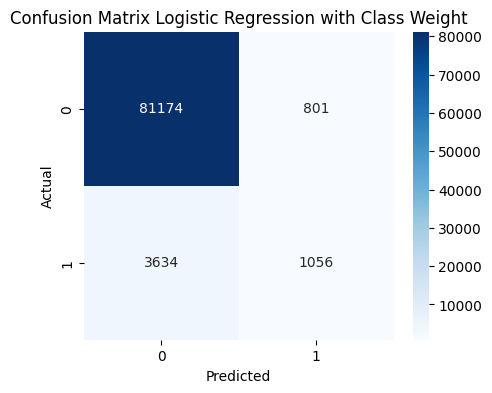

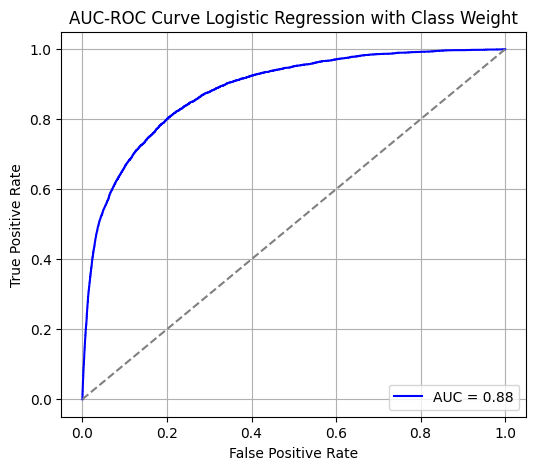

LogisticRegression(C=0.1, max_iter=1000, solver='liblinear')

In [12]:
train_and_evaluate(best_model, X_train, X_test, y_train, y_test, "Logistic Regression with Class Weight")

In [13]:
# Print final coefficients
print(f"🔹 Final Model Coefficients: {best_model.coef_}")

🔹 Final Model Coefficients: [[ 5.84634713e-01  1.34905680e-01  2.24224078e+00  9.78224824e-01
   3.05153458e-01 -2.90748685e-02  5.79522449e-01  2.41554613e-01
   1.37283864e-01  1.08286128e-01 -3.56867410e-01 -2.21754016e-03
   3.80543714e-03 -1.63108642e-01  5.21082753e-03  3.77997546e-01
   8.95087066e-02  6.85702572e-02 -2.37523149e-02 -3.22118735e-02]]


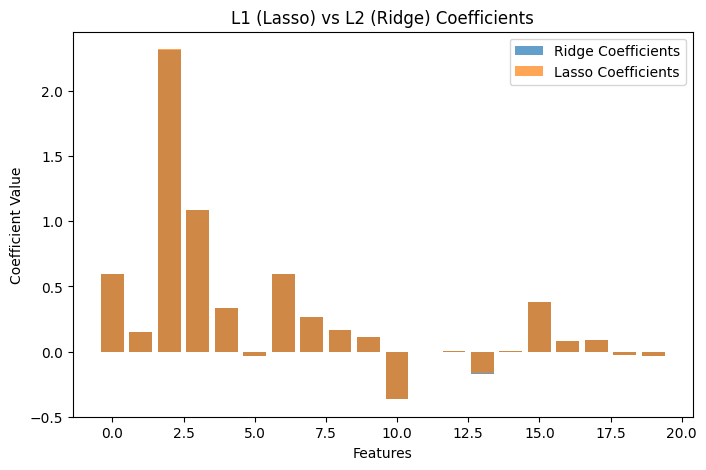

In [14]:
# Train models separately for L1 and L2 for comparison
lasso = LogisticRegression(class_weight=weights, penalty='l1', C=grid_search.best_params_['C'], solver='liblinear', max_iter=1000)
ridge = LogisticRegression(class_weight=weights, penalty='l2', C=grid_search.best_params_['C'], solver='liblinear', max_iter=1000)

lasso.fit(X, y)
ridge.fit(X, y)

plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), ridge.coef_.flatten(), label="Ridge Coefficients", alpha=0.7)
plt.bar(range(X.shape[1]), lasso.coef_.flatten(), label="Lasso Coefficients", alpha=0.7)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("L1 (Lasso) vs L2 (Ridge) Coefficients")
plt.legend()
plt.show();

In [15]:
save_model(best_model, "Logistic_Regression.pkl")

Model saved successfully as Model/Logistic_Regression.pkl
